In [3]:
from scipy.stats import norm, binom, expon
import numpy as numpy
from matplotlib import pyplot
import seaborn

## Нормальное распределение

Нормальное распределение $\mathcal{N}(\mu, \sigma^2)$ — непрерывное распределение, в котором плотность убывает с ростом расстояния от $\mu$ по экспоненте квадрата.

$$
f(x) = \frac{1}{\sigma\sqrt{2\pi}}e^{-\frac{1}{2}\left(\frac{x-\mu}{\sigma}\right)^2},
$$

где
- $\mu$ &mdash; параметр сдвига: насколько центр сдвинут относительно 0
- $\sigma^2$ &mdash; параметр масштаба: насколько "пологий" будет график распределения

<img src="https://raw.githubusercontent.com/dimalunin2016/pictures/main/image%20(8).png" width="1000" height="500" />


### Как пользоваться нормальным распределением в Python

Пусть мы хотим задать распределение $\mathcal{N}(\mu, \sigma^2)$. Для этого есть [класс](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.norm.html) `norm`. 

*Параметры инициализации*
- `loc` &mdash; это $\mu$
- `scale` &mdash; это $\sigma$, или **стандартное отклонение**. Не дисперсия!

Методы класса:
- `norm().cdf(x)` &mdash; функция распределения в точке x. $P(\xi \leq x)$
- `norm().ppf(q)` &mdash; получить квантиль распределения
- `norm().pdf(x)` &mdash; получить плотность распределения в точке x.

In [4]:
# инициализация
stand_norm = norm(loc=0, scale=1)

In [5]:
# cumulative distribution function
print(f"P(X <= 2)  = {stand_norm.cdf(x=2)}")
print(f"или так {norm(loc=0, scale=1).cdf(x=2)}")
# можно указывать массивы
print(f"[P(X <= 2), P(X <= -1)] = {stand_norm.cdf([2, -1])}")

P(X <= 2)  = 0.9772498680518208
или так 0.9772498680518208
[P(X <= 2), P(X <= -1)] = [0.97724987 0.15865525]


In [6]:
# percent point function
print(f"pdf(0) = {stand_norm.pdf(x=0)}")

pdf(0) = 0.3989422804014327


График нормального распределения:

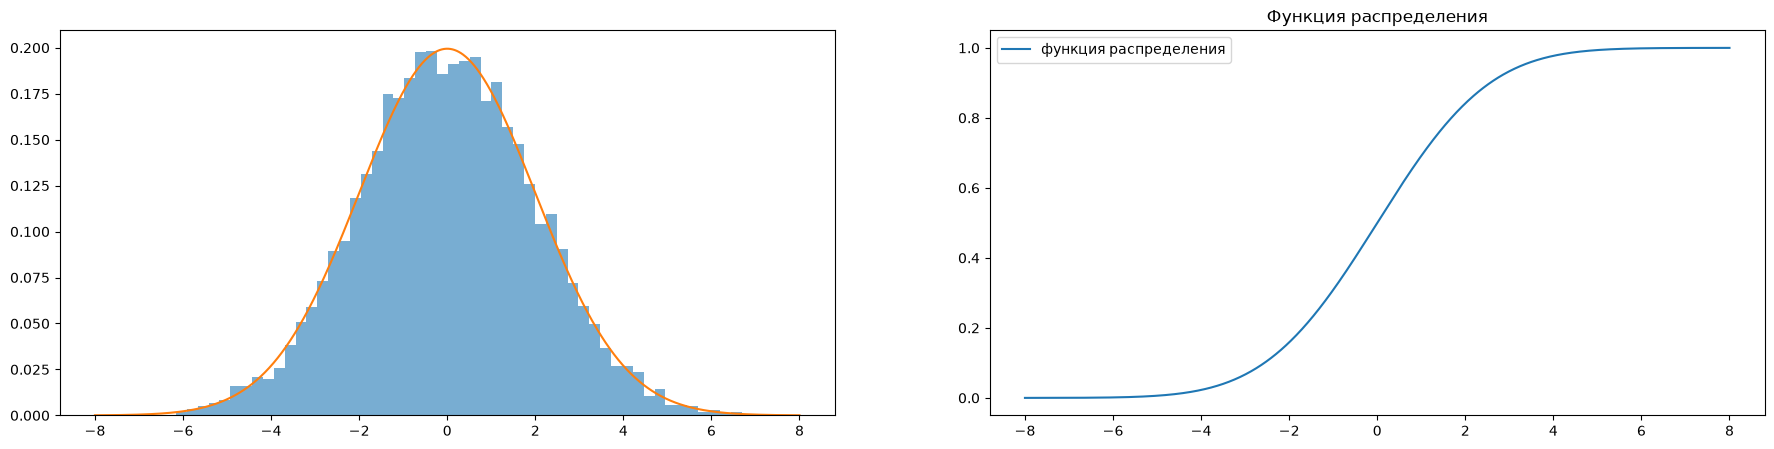

In [7]:
norm_distribution = norm(loc=0, scale=2)
x = numpy.linspace(-8, 8, 1000)
pdf = norm_distribution.pdf(x)
cdf = norm_distribution.cdf(x)
sample = norm_distribution.rvs(size=10000)

pyplot.figure(figsize=(22, 5))
pyplot.subplot(1, 2, 1)
pyplot.hist(
    sample, bins="auto", density=True, alpha=0.6, label="сгенерированные значения"
)  # rvs
pyplot.plot(x, pdf, label="плотность распределения")

pyplot.subplot(1, 2, 2)
pyplot.title("Функция распределения", fontsize=12)
pyplot.plot(x, cdf, label="функция распределения")

pyplot.legend()
pyplot.show()

### Свойства нормального распределения

- $\xi_1 \sim \mathcal{N}(\mu_1, \sigma_1^2),\ \xi_2 \sim \mathcal{N}(\mu_2, \sigma_2^2) \Rightarrow \xi_1 + \xi_2 \sim \mathcal{N}(\mu_1 + \mu_2, \sigma_1^2 + \sigma_2^2)$, [док-во](https://en.wikipedia.org/wiki/Sum_of_normally_distributed_random_variables#:~:text=This%20means%20that%20the%20sum,squares%20of%20the%20standard%20deviations)
- $a \xi_1 \sim \mathcal{N}(a\mu_1, a^2\sigma_1^2)$

Покажем корректность этих формул на практике:

Сначала проверим на примере формулу 1:

In [8]:
# примеры
first_mean = 3
first_var = 4

second_mean = -1
second_var = 2

first_dist = norm(loc=first_mean, scale=numpy.sqrt(first_var))
second_dist = norm(loc=second_mean, scale=numpy.sqrt(second_var))
# Важно scale=numpy.sqrt(first_var + second_var)
checking_sum_distr = norm(
    loc=first_mean + second_mean, scale=numpy.sqrt(first_var + second_var)
)

1. Нагенерируем выборку из 1 и 2 распределений и просуммируем их.
2. Далее, построим эмпирическую плотность распределения и сравним ее с настоящей на графике.

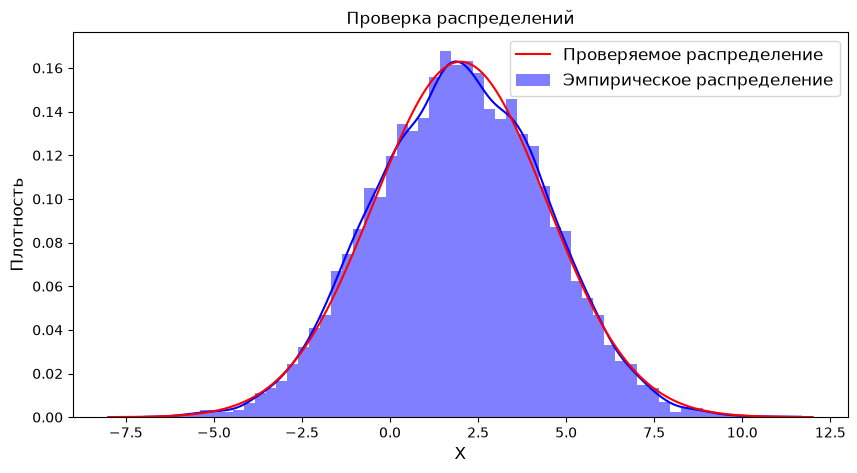

In [9]:
first_sample = first_dist.rvs(10000)
second_sample = second_dist.rvs(10000)
sum_sample = first_sample + second_sample

x = numpy.linspace(-8, 12, 1000)

pyplot.figure(figsize=(10, 5))
pyplot.title("Проверка распределений", fontsize=12)
seaborn.histplot(
    sum_sample,
    stat="density",
    kde=True,
    label="Эмпирическое распределение",
    color="blue",
    edgecolor=None
)
pyplot.plot(
    x, checking_sum_distr.pdf(x), label="Проверяемое распределение", color="red"
)
pyplot.legend(fontsize=12)
pyplot.xlabel("X", fontsize=12)
pyplot.ylabel("Плотность", fontsize=12)
pyplot.show()

In [10]:
a = 5
mean = 3
var = 4
dist = norm(loc=mean, scale=numpy.sqrt(var))
check_multiple_a_and_dist = norm(loc=a * mean, scale=numpy.sqrt(a**2 * var))

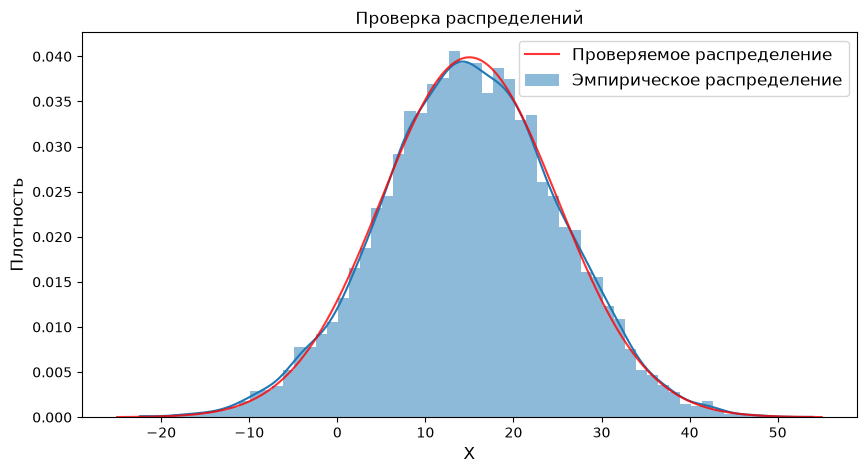

In [11]:
sample = dist.rvs(10000)
multiple_sample = a * sample

x_min = a * mean - 4 * numpy.sqrt(a**2 * var)
x_max = a * mean + 4 * numpy.sqrt(a**2 * var)
x = numpy.linspace(x_min, x_max, 1000)

pyplot.figure(figsize=(10, 5))
pyplot.title("Проверка распределений", fontsize=12)
seaborn.histplot(
    multiple_sample, stat="density", kde=True, label="Эмпирическое распределение", edgecolor=None
)
pyplot.plot(
    x,
    check_multiple_a_and_dist.pdf(x),
    label="Проверяемое распределение",
    color="red",
    alpha=0.8,
)
pyplot.legend(fontsize=12)
pyplot.xlabel("X", fontsize=12)
pyplot.ylabel("Плотность", fontsize=12)
pyplot.show()

## ЦПТ
Вспомним теорему, которая является основополагающей теоремой для всех критериев.

**Центральная предельная теорема**

*Формулировка теоремы*

Пусть $\xi_1, ..., \xi_n$ &mdash; **независимо** одинаково распределенные случайные величины, у которых сущестуют мат. ожидание и дисперсия: $E [\xi_i] = \mu < \infty$ и $Var[\xi_i] = \sigma^2 < \infty$. тогда $\sqrt{n}\dfrac{\overline \xi - \mu}{\sqrt{\sigma^2}}$ [сходится по распределению](https://en.wikipedia.org/wiki/Convergence_in_distribution) к $\mathcal{N}(0, 1)$.
Можно также написать эквивалентное выражение:
$$
\dfrac{\xi_1 + ... + \xi_n - n\mu}{\sqrt{\sigma^2}\sqrt{n}}
$$.
*Что это значит на практике*

Если случайные величины в эксперименте **независимы и одинаково распределены** и ваша выборка **достаточно большая**, то вы можете полагать, что 
$$
\sqrt{n}\dfrac{\overline \xi - \mu}{\sqrt{\sigma^2}} \sim \mathcal{N}(0, 1),
$$

где $\mu, \sigma^2$ &mdash; мат. ожидание и дисперсия одного элемента выборки.


*Дополнение*

Случайные величины могут быть слабо зависимы друг от друга и слегка по-разному распределены. Центральная предельная теорема все еще будет [верна](https://en.wikipedia.org/wiki/Stable_distribution#A_generalized_central_limit_theorem).


Несмотря на ослабление условий, **всегда держите в голове условия применимости ЦПТ**: забыв про них и не проверив свой критерий, вы можете некорректно проанализировать свой AB-тест.

### Визуализация ЦПТ

Визуализация теоремы: посмотрим на распределение средних значений в разных выборках. Как мы это сделаем?

- Чтобы посмотреть, что некоторая случайная величина из нормального распределения, нам нужна выборка этих случайных величин.
- В данном случае нам нужна выборка статистик из ЦПТ. Поэтому нам нужно нагенерировать N выборок по M элементов в каждой.
    - По каждой выборке надо посчитать нормированное среднее по M элементам.
    - В итоге мы получим выборку из N элементов.
    - Она и должна быть из нормального распределения.

In [12]:
def visualize_CLT(sample_generator, expected_value, variance):
    """
    Функция-визуализатор ЦПТ. Строит:
        - гисторгамму статистики ЦПТ,
        - эмпирическую плотность,
        - плотность нормального распределения.
    Параметры:
        - sample_generator: функция-генератор выборки. Не принимает ничего на вход
        - expected_value: мат. ожидание выборки
        - variance: дисперсия выборки
    """

    numpy.random.seed(42)
    N = 5000
    clt_sample = []
    for _ in range(N):
        sample = sample_generator()

        sample_size = len(sample)
        statistic = (
            numpy.sqrt(sample_size)
            * (numpy.mean(sample) - expected_value)
            / numpy.sqrt(variance)
        )
        clt_sample.append(statistic)

    x = numpy.linspace(-4, 4, 1000)
    pyplot.figure(figsize=(10, 5))
    pyplot.title("Распределение средних значений", fontsize=12)
    seaborn.histplot(clt_sample, stat='density', kde=True, bins=50, edgecolor=None, alpha=0.6, label='Эмпирическое распределение')
    pyplot.plot(x, norm(0,1).pdf(x), color='lightgreen', label=r"$\mathcal{N}(0, 1)$")
    pyplot.legend()
    pyplot.xlabel("X", fontsize=12)
    pyplot.ylabel("Плотность", fontsize=12)
    pyplot.show()

Проверим биномиальное распределение

In [13]:
def binom_generator(p, n, size):
    return binom(p=p, n=n).rvs(size)

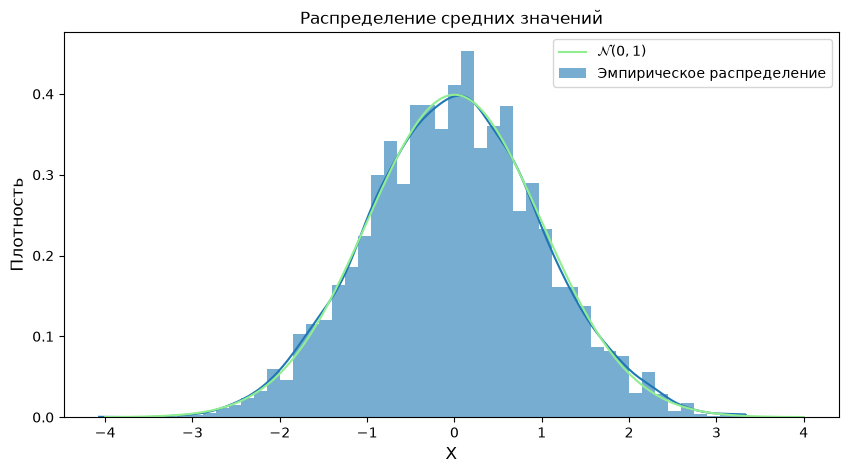

In [14]:
p = 0.01
n = 20
size = 5000

visualize_CLT(
    lambda: binom_generator(p, n, size), expected_value=n * p, variance=n * p * (1 - p)
)

Эмпирическая плотность "почти" совпала с истинной. А что если уменьшить выборку, по которой считается среднее?

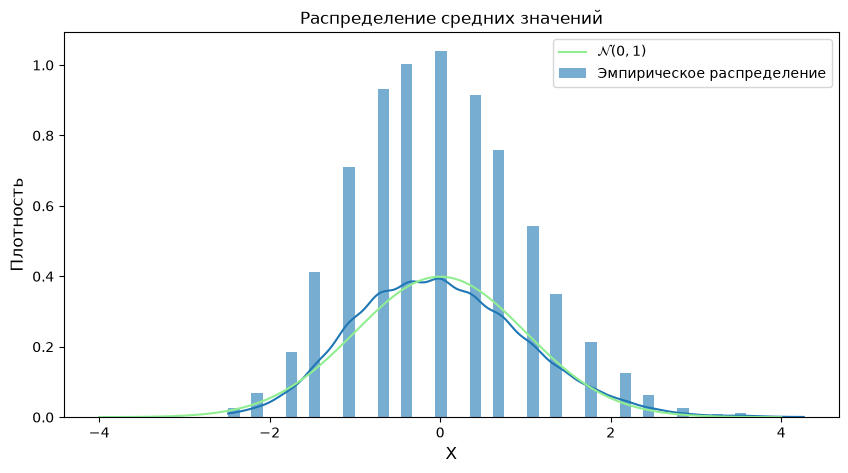

In [15]:
p = 0.01
n = 20
size = 40

visualize_CLT(lambda: binom_generator(p, n, size),
              expected_value = p * n,
              variance = n * p * (1 - p)
             )

Стало сильно хуже: появились пробелы в распределении, да и сама эмпирическая функция распределения слегка "сдвинута". Так что наш эксперимент подтвердил важность размера выборки для корректной работы ЦПТ.


Теперь давайте посмотрим на другое распределение: [экспоненциальное](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.expon.html).

In [16]:
def expon_generator(expected_value, size):
    return expon(scale=expected_value).rvs(size)

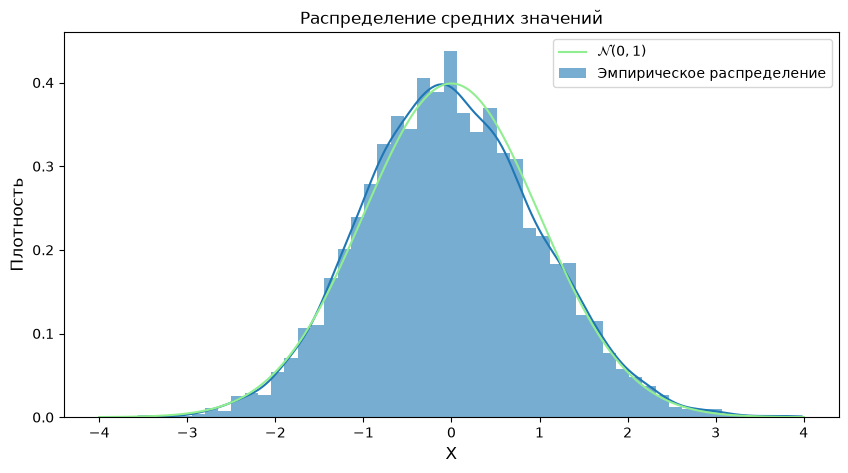

In [17]:
expected_value = 24
size = 400

visualize_CLT(lambda: expon_generator(expected_value, size),
              expected_value=expected_value, variance=expected_value ** 2)

Тут все хорошо работает

**Эквивалентные формулировки ЦПТ**

$$\begin{align}
\sqrt{n}\dfrac{\overline \xi - \mu}{\sqrt{\sigma^2}} &\sim \mathcal{N}(0, 1) \stackrel{св. 2}{\Leftrightarrow}\\
\overline \xi - \mu &\sim \mathcal{N}\left(0, \dfrac{\sigma^2}{n} \right) \Leftrightarrow\\
\dfrac{\underset{i=1}{\overset{n}{\sum}} \xi_i}{n} &\sim \mathcal{N}\left(\mu, \dfrac{\sigma^2}{n} \right) \Leftrightarrow\\
\underset{i=1}{\overset{n}{\sum}} \xi_i &\sim \mathcal{N}\left(n \cdot \mu, n \cdot \sigma^2 \right)
\end{align}$$

А значит сумма случайных величин также распределена нормально

## Z-критерий Фишера


> 📈 **Задача**
>
> Вы придумали идею для стартапа, где курьеры собирают заказы для клиентов и отвозят им на дом. Стоимость заказа в вашем стартапе &mdash; 10К ₽, а стоимость работы курьера &mdash; 5К ₽.
Специфика вашего стартапа такова, что есть большой риск возврата без оплаты. С учетом стоимостей, инвесторы готовы проспонсировать вам инфраструктуру и привлечение клиентов, если вы покажете, что шанс оплаты заказа больше 50%.
Вы своими силами обработали 30 заказов, 19 из них были успешно оплачены. Достаточно ли этих данных, чтобы убедить инвесторов?


У нас есть выборка $X_1,\ X_2,\ ...,\ X_n,\ X_i \sim \text{Bernoulli}(\mu)$

$H_0: \mu =\mu_0 = 0.5\ vs.\ H_1: \mu > 0.5$


**Как мы решали задачу ранее**

- $T(X^n) = \underset{i=1}{\overset{n}{\sum}} X_i,\ T \overset{H_0}{\sim} \text{Binom} (n, \mu_0)$
- Пусть реализация $T(X^n) = t$. Тогда 
- $\text{p-value} = P_{H_0}(T(X^n) \geq t) = 1 - P_{H_0}(T(X^n) < t)$
- Или, если переписать на языке Python `p-value = 1 - binom.cdf(t - 1, n, mu0)`

In [ ]:
def get_pvalue_by_old_logic(n, mu0, t):
    return 1 - binom(n, mu0).cdf(t-1)

In [19]:
n = 30
mu0 = 0.5
t = 19

old_p_value = get_pvalue_by_old_logic(n, mu0, t)
print(f"p-value, полученное по старой, корректной формуле: {old_p_value}")

p-value, полученное по старой, корректной формуле: 0.10024421103298664


А теперь посмотрим на ЦПТ.
- При достаточно большом размере выборки $\underset{i=1}{\overset{n}{\sum}} X_i \sim \mathcal{N}\left(n \cdot \mu_0, n \cdot \sigma^2 \right)$,
- $X_i \overset{H_0}{\sim} \text{Bernoulli} (\mu_0)$
- $\sigma^2 = \mu_0 \cdot (1 - \mu_0)$
- $\text{p-value} = P_{H_0}(T(X^n) \geq t)$. Или `p-value = 1 - norm(loc=sum_mu, scale=sum_std).cdf(t)`. При этом в этот раз мы смотрим статистику не в 
точке t-1, как делали ранее, а в точке t. **Так как у нас непрерывное распределение, то нам не нужно вычитать 1**:
    - в случае нормального распределения: $P(T(X^n) \geq t) = P(T(X^n) > t) = 1 - P(T(X^n) \leq t) $;
    - в случае биномиального распределения: $P(T(X^n) \geq t) = 1 - P(T(X^n) \leq t - 1)$.

In [20]:
def get_pvalue_by_normal_approx(n, mu0, t):
    sum_mu = n * mu0
    sum_variance = n * mu0 * (1 - mu0)
    sum_std = numpy.sqrt(sum_variance)
    return 1 - norm(loc=sum_mu, scale=sum_std).cdf(t)

In [21]:
normal_dist_p_value = get_pvalue_by_normal_approx(n, mu0, t)
print(f"p-value, полученное из приближения нормальным распределением: {normal_dist_p_value}")

p-value, полученное из приближения нормальным распределением: 0.07206351740800765


Попробуем повторить эксперимент с большим n.

In [23]:
n = 3000
mu0 = 0.5
t = 1544

old_p_value = get_pvalue_by_old_logic(n, mu0, t)
print(f"p-value, полученное по старой, корректной формуле: {old_p_value}")
normal_dist_p_value = get_pvalue_by_normal_approx(n, mu0, t)
print(f"p-value, полученное из приближения нормальным распределением: {normal_dist_p_value}")

p-value, полученное по старой, корректной формуле: 0.05609088374295823
p-value, полученное из приближения нормальным распределением: 0.05406527265575145


Но на самом деле, это **не Z-критерий Фишера** (не в чистом виде). Поэтому теперь рассмотрим искомый критерий.

### Z-критерий Фишера

$H_0: \mu =\mu_0\ vs.\ H_1: \mu > \mu_0$
- Статистика $Z(X) = \sqrt{n}\dfrac{\overline X - \mu_0}{\sqrt{\sigma^2}}$
- При достаточно большом размере выборки $Z(X) \overset{H_0}{\sim} \mathcal{N}(0, 1)$ (по ЦПТ)
- Односторонний критерий: $\left\{Z(X) \geq z_{1 - \alpha} \right\}$
    - p-value = $1 - \Phi(z)$, где z &mdash; реализация статистики $Z(X)$, $\Phi(z)$ &mdash; функция распределения $\mathcal{N}(0, 1)$
- Двусторонний критерий: $\left\{Z(X) \geq z_{1 - \frac{\alpha}{2}} \right\} \bigcup \left\{Z(X) \leq -z_{1 - \frac{\alpha}{2}} \right\} $
    - p-value = $2\cdot \min \left[{\Phi(z), 1 - \Phi(z)} \right]$, где z &mdash; реализация статистики $Z(X)$

In [ ]:
def z_criterion_pvalue(sample_mean, sample_size, mu0, variance):
    z_statistic = numpy.sqrt(sample_size) * (sample_mean - mu0) / numpy.sqrt(variance)
    return 1 - norm.cdf(z_statistic)

In [ ]:
n = 30
t = 19
mu0 = 0.5
variance = mu0 * (1 - mu0)

old_p_value = get_pvalue_by_old_logic(n, mu0, t)
print(f"p-value, полученное по старой, корректной формуле: {old_p_value}")
normal_p_value = get_pvalue_by_normal_approx(n, mu0, t)
print(f"p-value, полученное по нормальному приближению: {normal_p_value}")
z_value = z_criterion_pvalue(t/n, n, mu0, variance)
print(f"p-value, полученное по критерию z: {z_value}")

p-value, полученное по старой, корректной формуле: 0.10024421103298664
p-value, полученное по нормальному приближению: 0.07206351740800765
p-value, полученное по критерию z: 0.07206351740800765


Z-критерий совпадает с предыдущим нормальным приближением, то есть критерии эквивалентны.